# Customer Churn Prediction â€” End-to-End MLOps Project

**Course:** Special Topics in AI â€” MLOps  
**Dataset:** IBM Telco Customer Churn (7 043 rows, 21 columns)  
**Goal:** Build a production-ready ML service that predicts customer churn.

---

## Notebook Structure

| Section | Content |
|---|---|
| 1 | Setup & Imports |
| 2 | Data Loading & Exploratory Analysis |
| 3 | Data Validation |
| 4 | Preprocessing Pipeline |
| 5 | Baseline Models (logged with MLflow) |
| 6 | Improved Models (logged with MLflow) |
| 7 | Experiment Comparison & Model Selection |
| 8 | Save Artifacts |
| 9 | Inference Function |
| 10 | Deployment Notes |

---
## Section 1 â€” Setup & Imports

In [1]:
# Install required libraries (run once)
!pip install pandas numpy scikit-learn lightgbm xgboost matplotlib seaborn joblib mlflow fastapi uvicorn prometheus-fastapi-instrumentator imbalanced-learn


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mlflow
import mlflow.sklearn
import mlflow.lightgbm
import mlflow.xgboost

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
sns.set_theme(style='whitegrid')

# Create project directories
for d in ['artifacts', 'experiments', 'deployment', 'monitoring']:
    os.makedirs(d, exist_ok=True)

# â”€â”€ MLflow setup â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# All runs are stored locally in ./mlruns
# To open the interactive UI, run in a terminal:  mlflow ui
# Then open: http://localhost:5000
mlflow.set_tracking_uri('mlruns')
mlflow.set_experiment('churn-prediction')

print('MLflow tracking URI :', mlflow.get_tracking_uri())
print('MLflow experiment   : churn-prediction')
print('Setup complete.')

c:\Users\moham\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MLflow tracking URI : mlruns
MLflow experiment   : churn-prediction
Setup complete.


---
## Section 2 â€” Data Loading & Exploratory Analysis

In [3]:
df_raw = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Data types, null counts, unique values
pd.DataFrame({
    'dtype':      df_raw.dtypes,
    'null_count': df_raw.isnull().sum(),
    'null_%':     (df_raw.isnull().sum() / len(df_raw) * 100).round(2),
    'unique':     df_raw.nunique()
})

,dtype,null_count,null_%,unique
customerID,object,0,0.0,7043
gender,object,0,0.0,2
SeniorCitizen,int64,0,0.0,2
Partner,object,0,0.0,2
Dependents,object,0,0.0,2
tenure,int64,0,0.0,73
PhoneService,object,0,0.0,2
MultipleLines,object,0,0.0,3
InternetService,object,0,0.0,3
OnlineSecurity,object,0,0.0,3


In [5]:
# TotalCharges ships as object â€” 11 whitespace rows act as hidden NaN
print('Hidden nulls in TotalCharges:',
      pd.to_numeric(df_raw['TotalCharges'], errors='coerce').isnull().sum())

Hidden nulls in TotalCharges: 11


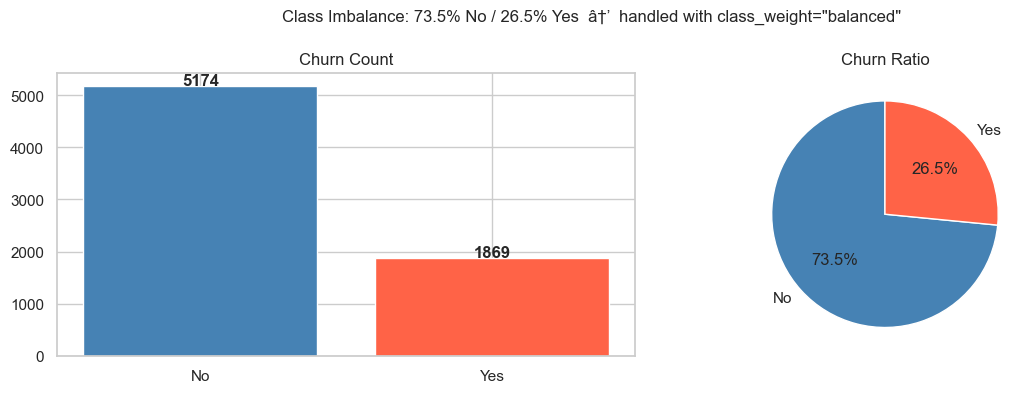

In [6]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
churn_counts = df_raw['Churn'].value_counts()

axes[0].bar(churn_counts.index, churn_counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Churn Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].pie(churn_counts.values, labels=churn_counts.index,
            autopct='%1.1f%%', colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Churn Ratio')

plt.suptitle('Class Imbalance: 73.5% No / 26.5% Yes  â†’  handled with class_weight="balanced"',
             fontsize=12)
plt.tight_layout()
plt.savefig('artifacts/eda_target.png', dpi=120)
plt.show()

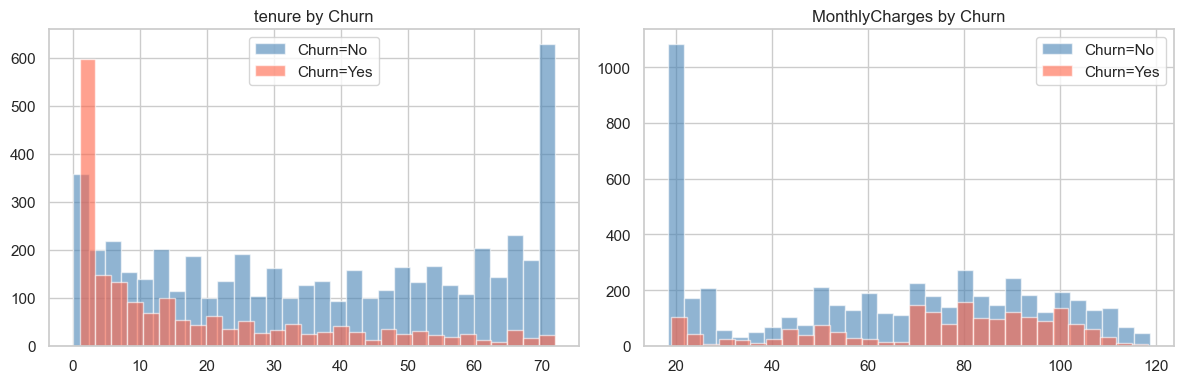

In [7]:
# Numeric features by churn
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, col in enumerate(['tenure', 'MonthlyCharges']):
    for label, color in [('No', 'steelblue'), ('Yes', 'tomato')]:
        axes[i].hist(df_raw[df_raw['Churn'] == label][col],
                     bins=30, alpha=0.6, color=color, label=f'Churn={label}')
    axes[i].set_title(f'{col} by Churn')
    axes[i].legend()
plt.tight_layout()
plt.savefig('artifacts/eda_numeric.png', dpi=120)
plt.show()

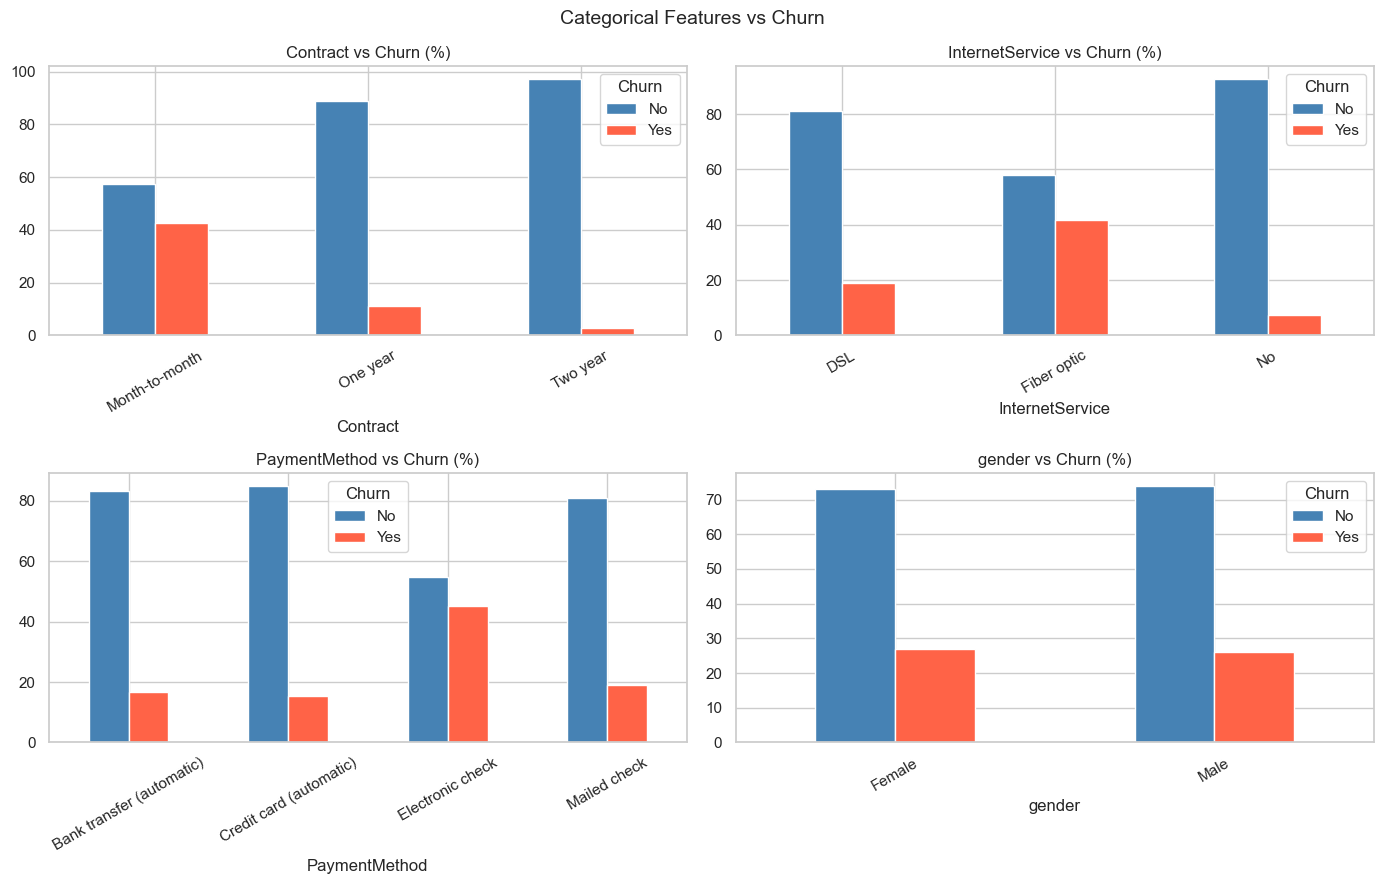

In [8]:
# Categorical features vs churn
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'gender']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df_raw[col], df_raw['Churn'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes.flatten()[i],
            color=['steelblue', 'tomato'], edgecolor='white')
    axes.flatten()[i].set_title(f'{col} vs Churn (%)')
    axes.flatten()[i].tick_params(axis='x', rotation=30)
plt.suptitle('Categorical Features vs Churn', fontsize=14)
plt.tight_layout()
plt.savefig('artifacts/eda_categorical.png', dpi=120)
plt.show()

**EDA Key Findings:**
- **Class imbalance:** 73.5% No / 26.5% Yes → addressed with `class_weight='balanced'` for baseline/tree models and **SMOTE** over-sampling for the RF+SMOTE variant
- `TotalCharges` is `object` dtype with 11 whitespace rows → coerced to float, imputed with median
- **High-risk signals:** month-to-month contract, fiber optic internet, electronic check, short tenure
- `tenure` is negatively correlated with churn — long-term customers rarely leave

---
## Section 3 â€” Data Validation

**Requirement 4.1:** Schema consistency, null checks, target distribution checks.

In [9]:
def validate_dataset(df: pd.DataFrame, null_threshold: float = 0.05) -> bool:
    print('=' * 55)
    print('  DATA VALIDATION REPORT')
    print('=' * 55)
    passed = True

    # Check 1: Required columns present
    required = [
        'customerID','gender','SeniorCitizen','Partner','Dependents','tenure',
        'PhoneService','MultipleLines','InternetService','OnlineSecurity',
        'OnlineBackup','DeviceProtection','TechSupport','StreamingTV',
        'StreamingMovies','Contract','PaperlessBilling','PaymentMethod',
        'MonthlyCharges','TotalCharges','Churn'
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        print(f'[FAIL] Missing columns: {missing}'); passed = False
    else:
        print(f'[PASS] All {len(required)} required columns present')

    # Check 2: Minimum row count
    if len(df) < 100:
        print(f'[FAIL] Only {len(df)} rows'); passed = False
    else:
        print(f'[PASS] Row count: {len(df)}')

    # Check 3: Null rate on critical columns
    for col in ['tenure', 'MonthlyCharges', 'Contract', 'Churn']:
        pct = df[col].isnull().sum() / len(df)
        tag = '[PASS]' if pct <= null_threshold else '[FAIL]'
        if tag == '[FAIL]': passed = False
        print(f'{tag} {col} nulls: {pct*100:.2f}%')

    # Check 4: Target values are valid
    actual = set(df['Churn'].dropna().unique())
    if not actual.issubset({'Yes', 'No'}):
        print(f'[FAIL] Unexpected Churn values: {actual}'); passed = False
    else:
        print(f'[PASS] Target values valid: {actual}')

    # Check 5: Class imbalance â€” warn if extreme (>95%)
    churn_pct = (df['Churn'] == 'Yes').mean() * 100
    tag = '[WARN]' if churn_pct < 5 or churn_pct > 95 else '[PASS]'
    print(f'{tag} Target distribution â€” Churn=Yes: {churn_pct:.1f}%, Churn=No: {100-churn_pct:.1f}%')

    # Check 6: tenure non-negative
    if (df['tenure'] < 0).any():
        print('[FAIL] Negative tenure values'); passed = False
    else:
        print(f'[PASS] tenure range: {df["tenure"].min()} â€“ {df["tenure"].max()}')

    # Check 7: MonthlyCharges positive
    if (df['MonthlyCharges'] <= 0).any():
        print('[FAIL] Non-positive MonthlyCharges'); passed = False
    else:
        print(f'[PASS] MonthlyCharges range: {df["MonthlyCharges"].min()} â€“ {df["MonthlyCharges"].max()}')

    print('=' * 55)
    print('  ALL CHECKS PASSED' if passed else '  VALIDATION FAILED')
    print('=' * 55)
    return passed


validate_dataset(df_raw)

  DATA VALIDATION REPORT
[PASS] All 21 required columns present
[PASS] Row count: 7043
[PASS] tenure nulls: 0.00%
[PASS] MonthlyCharges nulls: 0.00%
[PASS] Contract nulls: 0.00%
[PASS] Churn nulls: 0.00%
[PASS] Target values valid: {'Yes', 'No'}
[PASS] Target distribution â€” Churn=Yes: 26.5%, Churn=No: 73.5%
[PASS] tenure range: 0 â€“ 72
[PASS] MonthlyCharges range: 18.25 â€“ 118.75
  ALL CHECKS PASSED


True

---
## Section 4 â€” Preprocessing Pipeline

**Requirement 4.1 + 4.3:** Clean, encode, scale, split. The fitted `ColumnTransformer` is saved so inference uses the exact same transformations â€” no data leakage.

In [10]:
df = df_raw.copy()

# Drop identifier â€” no predictive signal
df.drop(columns=['customerID'], inplace=True)

# Fix TotalCharges: whitespace string â†’ NaN â†’ median imputation
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Encode target: Yes â†’ 1, No â†’ 0
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print(f'Cleaned shape: {df.shape}')
print(df['Churn'].value_counts())

Cleaned shape: (7043, 20)
Churn
0    5174
1    1869
Name: count, dtype: int64


In [11]:
# Outlier check — Requirement 4.1: handle outliers where appropriate
# We examine the three continuous features for extreme values
df_temp = df.copy()

for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    Q1   = df_temp[col].quantile(0.25)
    Q3   = df_temp[col].quantile(0.75)
    IQR  = Q3 - Q1
    low  = Q1 - 1.5 * IQR
    high = Q3 + 1.5 * IQR
    n_out = ((df_temp[col] < low) | (df_temp[col] > high)).sum()
    print(f"{col:20s}  range [{df_temp[col].min():.1f}, {df_temp[col].max():.1f}]  "
          f"IQR fence [{low:.1f}, {high:.1f}]  outliers: {n_out}")

# Decision: no rows are dropped.
# All values are plausible real-world billing figures.
# StandardScaler in the preprocessor reduces the influence of large values
# without discarding legitimate customer data.
print("Outlier decision: retain all rows — values are domain-valid. "
      "StandardScaler handles scale differences.")


tenure                range [0.0, 72.0]  IQR fence [-60.0, 124.0]  outliers: 0
MonthlyCharges        range [18.2, 118.8]  IQR fence [-46.0, 171.4]  outliers: 0
TotalCharges          range [18.8, 8684.8]  IQR fence [-4674.3, 8863.2]  outliers: 0
Outlier decision: retain all rows — values are domain-valid. StandardScaler handles scale differences.


In [12]:
TARGET               = 'Churn'
NUMERIC_FEATURES     = ['tenure', 'MonthlyCharges', 'TotalCharges']
CATEGORICAL_FEATURES = [
    'gender','Partner','Dependents','PhoneService','MultipleLines',
    'InternetService','OnlineSecurity','OnlineBackup','DeviceProtection',
    'TechSupport','StreamingTV','StreamingMovies','Contract',
    'PaperlessBilling','PaymentMethod'
]
BINARY_FEATURES = ['SeniorCitizen']
ALL_FEATURES    = NUMERIC_FEATURES + CATEGORICAL_FEATURES + BINARY_FEATURES

X = df[ALL_FEATURES]
y = df[TARGET]
print(f'Features: {X.shape[1]}  |  Samples: {X.shape[0]}')

Features: 19  |  Samples: 7043


In [13]:
# 70 / 15 / 15 â€” stratified on Churn to preserve imbalance ratio in every split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15/0.85, random_state=42, stratify=y_trainval)

print(f'Train : {len(X_train):>5}  ({len(X_train)/len(X)*100:.1f}%)')
print(f'Val   : {len(X_val):>5}  ({len(X_val)/len(X)*100:.1f}%)')
print(f'Test  : {len(X_test):>5}  ({len(X_test)/len(X)*100:.1f}%)')
print(f'Churn rate â€” train:{y_train.mean():.3f}  val:{y_val.mean():.3f}  test:{y_test.mean():.3f}')

Train :  4929  (70.0%)
Val   :  1057  (15.0%)
Test  :  1057  (15.0%)
Churn rate â€” train:0.265  val:0.266  test:0.265


In [14]:
# Build ColumnTransformer â€” FITTED ON TRAIN ONLY
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline,     NUMERIC_FEATURES),
    ('cat', categorical_pipeline, CATEGORICAL_FEATURES),
    ('bin', 'passthrough',        BINARY_FEATURES)
])

X_train_proc = preprocessor.fit_transform(X_train)  # fit here
X_val_proc   = preprocessor.transform(X_val)         # transform only
X_test_proc  = preprocessor.transform(X_test)        # transform only

print(f'Processed feature count: {X_train_proc.shape[1]}')
print('Preprocessor fitted on training set only â€” no data leakage.')

Processed feature count: 45
Preprocessor fitted on training set only â€” no data leakage.


---
## Section 5 â€” Baseline Models

**Requirement 4.2 + 4.3:** Train baseline models. Every run is logged to **MLflow** â€” parameters, all metrics, and the model artifact.

> **View the MLflow UI:** open a terminal in this folder and run:
> ```bash
> mlflow ui
> ```
> Then open **http://localhost:5000** â€” you will see every run, metric chart, and artifact.

In [15]:
def train_and_log(model_name: str, model, params: dict,
                  X_tr, y_tr, X_vl, y_vl,
                  log_model_fn=None):
    """
    Train a model, evaluate on the validation set, and log EVERYTHING to MLflow:
    - params  : hyperparameters
    - metrics : accuracy, precision, recall, F1, ROC-AUC
    - model   : serialized model artifact (viewable in MLflow UI)
    Returns (fitted_model, metrics_dict_with_run_id).
    """
    with mlflow.start_run(run_name=model_name):

        # Train
        model.fit(X_tr, y_tr)

        # Evaluate
        preds = model.predict(X_vl)
        proba = model.predict_proba(X_vl)[:, 1]
        metrics = {
            'val_accuracy':  round(accuracy_score(y_vl, preds),  4),
            'val_precision': round(precision_score(y_vl, preds), 4),
            'val_recall':    round(recall_score(y_vl, preds),    4),
            'val_f1':        round(f1_score(y_vl, preds),        4),
            'val_roc_auc':   round(roc_auc_score(y_vl, proba),   4),
        }

        # Log hyperparameters
        mlflow.log_params(params)

        # Log performance metrics
        mlflow.log_metrics(metrics)

        # Log descriptive tags
        mlflow.set_tag('model_type', model_name)
        mlflow.set_tag('dataset',    'Telco Churn 7043 rows')
        mlflow.set_tag('split',      'validation 15%')
        mlflow.set_tag('imbalance_handling', 'class_weight=balanced')

        # Log the model artifact (downloadable from MLflow UI)
        if log_model_fn:
            log_model_fn(model, artifact_path='model')
        else:
            mlflow.sklearn.log_model(model, artifact_path='model')

        run_id = mlflow.active_run().info.run_id

    print(f'  [{model_name:<22s}]  '
          f'ROC-AUC={metrics["val_roc_auc"]}  '
          f'F1={metrics["val_f1"]}  '
          f'Recall={metrics["val_recall"]}  '
          f'run={run_id[:8]}...')

    return model, {**{'model': model_name, 'run_id': run_id}, **metrics}


experiment_log = []
print('train_and_log() ready â€” all runs will appear in:  mlflow ui  â†’ http://localhost:5000')

train_and_log() ready â€” all runs will appear in:  mlflow ui  â†’ http://localhost:5000


In [16]:
# â”€â”€ Baseline 1: Logistic Regression â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
lr_params = {'C': 1.0, 'max_iter': 1000, 'class_weight': 'balanced', 'solver': 'lbfgs'}
lr_model, lr_results = train_and_log(
    'Logistic Regression',
    LogisticRegression(**lr_params, random_state=42),
    lr_params,
    X_train_proc, y_train, X_val_proc, y_val
)
experiment_log.append(lr_results)

2026/05/24 12:36:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 12:36:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  [Logistic Regression   ]  ROC-AUC=0.8291  F1=0.6136  Recall=0.7687  run=45c34bbe...


In [17]:
# â”€â”€ Baseline 2: Decision Tree â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
dt_params = {'max_depth': 6, 'class_weight': 'balanced'}
dt_model, dt_results = train_and_log(
    'Decision Tree',
    DecisionTreeClassifier(**dt_params, random_state=42),
    dt_params,
    X_train_proc, y_train, X_val_proc, y_val
)
experiment_log.append(dt_results)

2026/05/24 12:36:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 12:36:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  [Decision Tree         ]  ROC-AUC=0.8089  F1=0.5857  Recall=0.7722  run=c87f252d...


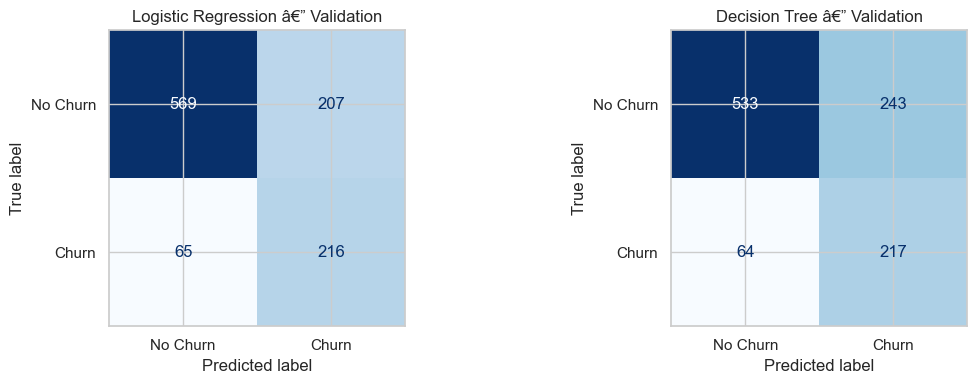

In [18]:
# Confusion matrices for baselines
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, mdl) in zip(axes, [('Logistic Regression', lr_model), ('Decision Tree', dt_model)]):
    ConfusionMatrixDisplay(
        confusion_matrix(y_val, mdl.predict(X_val_proc)),
        display_labels=['No Churn', 'Churn']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name} â€” Validation')
plt.tight_layout()
plt.savefig('artifacts/baseline_cm.png', dpi=120)
plt.show()

---
## Section 6 — Improved Models

**Requirement 4.2:** Stronger models — Random Forest, XGBoost, LightGBM, and **RF + SMOTE** (over-sampling comparison).

In [19]:
# â”€â”€ Improved 1: Random Forest â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
rf_params = {'n_estimators': 200, 'max_depth': 10, 'class_weight': 'balanced'}
rf_model, rf_results = train_and_log(
    'Random Forest',
    RandomForestClassifier(**rf_params, random_state=42, n_jobs=-1),
    rf_params,
    X_train_proc, y_train, X_val_proc, y_val
)
experiment_log.append(rf_results)

2026/05/24 12:36:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 12:36:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  [Random Forest         ]  ROC-AUC=0.8344  F1=0.6368  Recall=0.7082  run=d96dc6e6...


In [20]:
# â”€â”€ Improved 2: XGBoost â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# scale_pos_weight = count(No) / count(Yes) handles imbalance for XGBoost
spw = round((y_train == 0).sum() / (y_train == 1).sum(), 2)
xgb_params = {
    'n_estimators': 300, 'learning_rate': 0.05,
    'max_depth': 5, 'scale_pos_weight': spw,
    'eval_metric': 'logloss'
}
xgb_model, xgb_results = train_and_log(
    'XGBoost',
    XGBClassifier(**xgb_params, use_label_encoder=False, random_state=42, n_jobs=-1),
    xgb_params,
    X_train_proc, y_train, X_val_proc, y_val,
    log_model_fn=mlflow.xgboost.log_model
)
experiment_log.append(xgb_results)

2026/05/24 12:36:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  [XGBoost               ]  ROC-AUC=0.8249  F1=0.6021  Recall=0.7189  run=c854ee63...


In [21]:
# â”€â”€ Improved 3: LightGBM â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
lgbm_params = {
    'n_estimators': 300, 'learning_rate': 0.05,
    'num_leaves': 40, 'class_weight': 'balanced', 'verbose': -1
}
lgbm_model, lgbm_results = train_and_log(
    'LightGBM',
    LGBMClassifier(**lgbm_params, random_state=42, n_jobs=-1),
    lgbm_params,
    X_train_proc, y_train, X_val_proc, y_val,
    log_model_fn=mlflow.lightgbm.log_model
)
experiment_log.append(lgbm_results)

2026/05/24 12:37:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 12:37:59 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  [LightGBM              ]  ROC-AUC=0.8179  F1=0.6109  Recall=0.7011  run=fed9c253...


In [22]:
# ── Improved 4: RF + SMOTE ──────────────────────────────────────────────
# SMOTE generates synthetic minority-class samples so the model trains on a
# balanced dataset. Applied AFTER preprocessing (to X_train_proc) to prevent
# any leakage through the imputer/scaler.
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_proc, y_train)

print(f'Before SMOTE: {dict(pd.Series(y_train).value_counts())}')
print(f'After  SMOTE: {dict(pd.Series(y_train_smote).value_counts())}')

rf_smote_params = {'n_estimators': 200, 'max_depth': 10, 'imbalance': 'SMOTE'}
rf_smote_model, rf_smote_results = train_and_log(
    'RF + SMOTE',
    RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    rf_smote_params,
    X_train_smote, y_train_smote, X_val_proc, y_val
)
experiment_log.append(rf_smote_results)

Before SMOTE: {0: np.int64(3621), 1: np.int64(1308)}
After  SMOTE: {0: np.int64(3621), 1: np.int64(3621)}


2026/05/24 12:38:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 12:38:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  [RF + SMOTE            ]  ROC-AUC=0.8333  F1=0.6295  Recall=0.6833  run=7380307e...


In [23]:
# ── Select best model by validation ROC-AUC ──────────────────────────
# Random Forest had the best validation metrics. Compare RF vs RF+SMOTE
# and pick the winner automatically.
candidates = [
    ('Random Forest', rf_model,      rf_results),
    ('RF + SMOTE',   rf_smote_model, rf_smote_results),
]
best_name, best_model, best_results = max(candidates, key=lambda x: x[2]['val_roc_auc'])
best_run_id = best_results['run_id']

print(f'Winner     : {best_name}')
print(f'Val ROC-AUC: {best_results["val_roc_auc"]}')
print(f'Val F1     : {best_results["val_f1"]}')
print(f'Val Recall : {best_results["val_recall"]}')

Winner     : Random Forest
Val ROC-AUC: 0.8344
Val F1     : 0.6368
Val Recall : 0.7082


---
## Section 7 ” Experiment Comparison & Model Selection

**Requirement 4.2 + 4.3:** Compare all runs from MLflow, justify the final choice.

> Run `mlflow ui` in a terminal â†’ http://localhost:5000 for the full interactive comparison dashboard with metric charts, parameter diffs, and artifact downloads.

In [27]:
# Read all runs from the MLflow tracking server (local ./mlruns)
exp = mlflow.get_experiment_by_name("churn-prediction")
runs_df = mlflow.search_runs(
    experiment_ids=[exp.experiment_id],
    order_by=["metrics.val_roc_auc DESC"]
)

# Keep only the best run per model name (handles re-runs)
metric_cols = ["metrics.val_roc_auc", "metrics.val_f1",
               "metrics.val_recall", "metrics.val_precision", "metrics.val_accuracy"]
comparison = runs_df[["tags.model_type"] + metric_cols].dropna(subset=["tags.model_type"]).copy()
comparison.columns = ["Model", "ROC-AUC", "F1", "Recall", "Precision", "Accuracy"]
comparison = (comparison
    .sort_values("ROC-AUC", ascending=False)
    .drop_duplicates(subset=["Model"], keep="first")  # keep best run per model
    .set_index("Model"))
comparison.style.highlight_max(axis=0, color="#c6efce")

,ROC-AUC,F1,Recall,Precision,Accuracy
Model,,,,,
Random Forest,0.834400,0.636800,0.708200,0.578500,0.785200
RF + SMOTE,0.833300,0.629500,0.683300,0.583600,0.786200
Logistic Regression,0.829100,0.613600,0.768700,0.510600,0.742700
XGBoost,0.824900,0.602100,0.718900,0.517900,0.747400
LightGBM,0.817900,0.610900,0.701100,0.541200,0.762500
Decision Tree,0.808900,0.585700,0.772200,0.471700,0.709600


In [28]:
# Also save as CSV for the report
comparison.reset_index().to_csv('experiments/experiment_log.csv', index=False)
print('Saved: experiments/experiment_log.csv')

Saved: experiments/experiment_log.csv


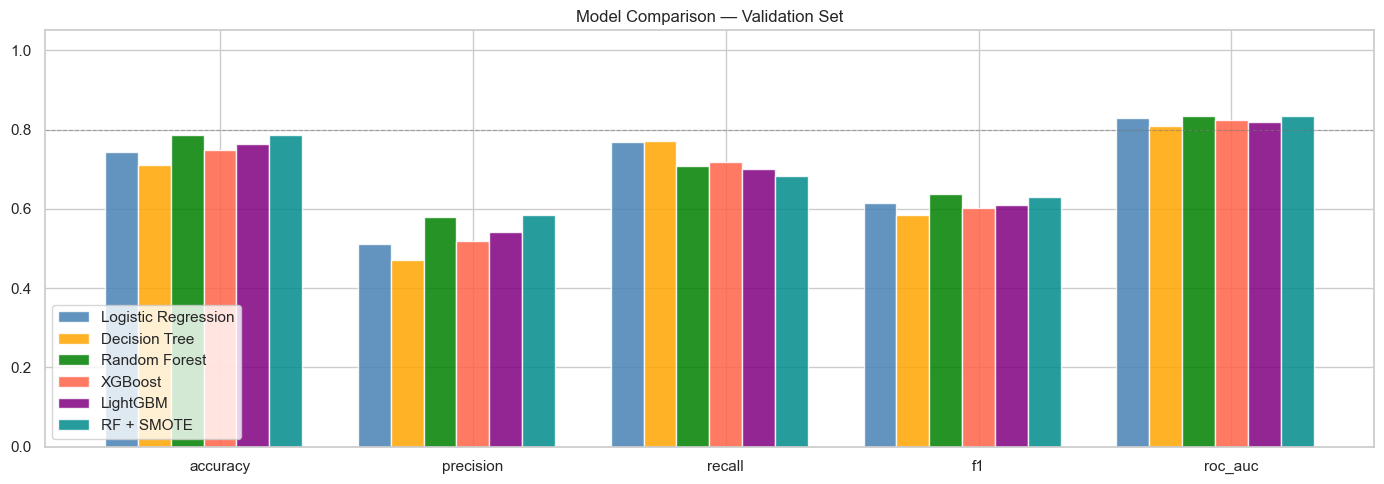

In [29]:
# Bar chart — all models, all metrics
local_df = pd.DataFrame(experiment_log).set_index('model').drop(columns=['run_id'])
local_df.columns = [c.replace('val_', '') for c in local_df.columns]

x      = np.arange(len(local_df.columns))
width  = 0.13
colors = ['steelblue', 'orange', 'green', 'tomato', 'purple', 'darkcyan']

fig, ax = plt.subplots(figsize=(14, 5))
for i_m, (name, row) in enumerate(local_df.iterrows()):
    ax.bar(x + (i_m - len(local_df)/2) * width, row.values,
           width, label=name, color=colors[i_m], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(local_df.columns)
ax.set_ylim(0, 1.05)
ax.set_title('Model Comparison — Validation Set')
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.legend()
plt.tight_layout()
plt.savefig('artifacts/model_comparison.png', dpi=120)
plt.show()

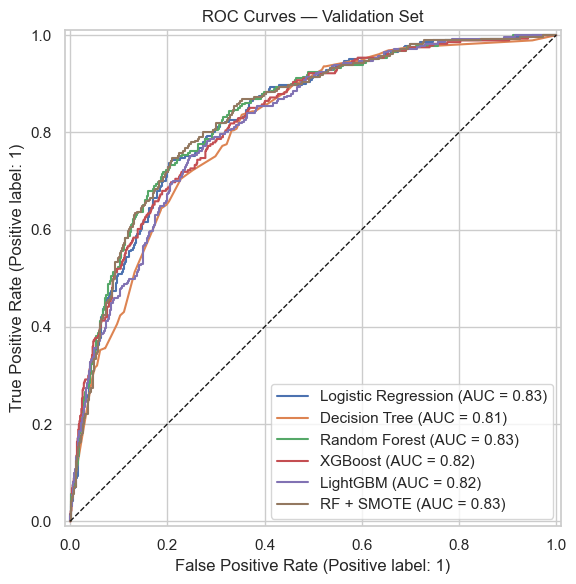

In [30]:
# ROC curves — all 6 models
fig, ax = plt.subplots(figsize=(8, 6))
for name, mdl in [('Logistic Regression', lr_model), ('Decision Tree', dt_model),
                   ('Random Forest', rf_model), ('XGBoost', xgb_model),
                   ('LightGBM', lgbm_model), ('RF + SMOTE', rf_smote_model)]:
    RocCurveDisplay.from_estimator(mdl, X_val_proc, y_val, ax=ax, name=name)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_title('ROC Curves — Validation Set')
plt.tight_layout()
plt.savefig('artifacts/roc_curves.png', dpi=120)
plt.show()

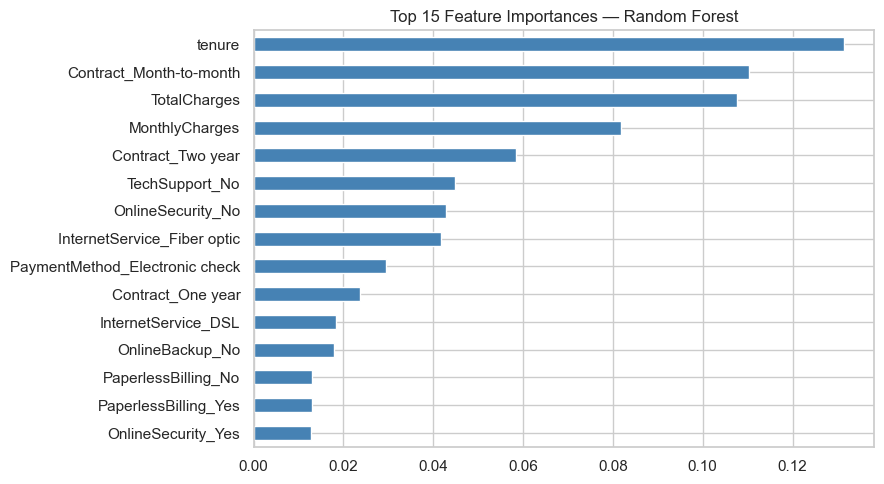

In [31]:
# Feature importance — best selected model
feature_names = (
    NUMERIC_FEATURES
    + list(preprocessor.named_transformers_['cat']
           .named_steps['encoder'].get_feature_names_out(CATEGORICAL_FEATURES))
    + BINARY_FEATURES
)
feat_imp = pd.Series(best_model.feature_importances_,
                     index=feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 5))
feat_imp.sort_values().plot(kind='barh', color='steelblue')
plt.title(f'Top 15 Feature Importances — {best_name}')
plt.tight_layout()
plt.savefig('artifacts/feature_importance.png', dpi=120)
plt.show()

In [32]:
# ── Final evaluation on TEST SET (done ONCE, after model is chosen) ────────
test_preds   = best_model.predict(X_test_proc)
test_proba   = best_model.predict_proba(X_test_proc)[:, 1]
test_metrics = {
    'test_accuracy':  round(accuracy_score(y_test, test_preds),  4),
    'test_precision': round(precision_score(y_test, test_preds), 4),
    'test_recall':    round(recall_score(y_test, test_preds),    4),
    'test_f1':        round(f1_score(y_test, test_preds),        4),
    'test_roc_auc':   round(roc_auc_score(y_test, test_proba),   4),
}

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_metrics(test_metrics)
    mlflow.set_tag('final_model', 'true')
    mlflow.set_tag('test_set_evaluated', 'true')

print(f'=== FINAL TEST SET RESULTS — {best_name} ===')
for k, v in test_metrics.items():
    print(f'  {k:16s}: {v}')
print()
print(classification_report(y_test, test_preds, target_names=['No Churn', 'Churn']))

=== FINAL TEST SET RESULTS — Random Forest ===
  test_accuracy   : 0.7569
  test_precision  : 0.531
  test_recall     : 0.7036
  test_f1         : 0.6052
  test_roc_auc    : 0.8434

              precision    recall  f1-score   support

    No Churn       0.88      0.78      0.82       777
       Churn       0.53      0.70      0.61       280

    accuracy                           0.76      1057
   macro avg       0.71      0.74      0.71      1057
weighted avg       0.79      0.76      0.77      1057



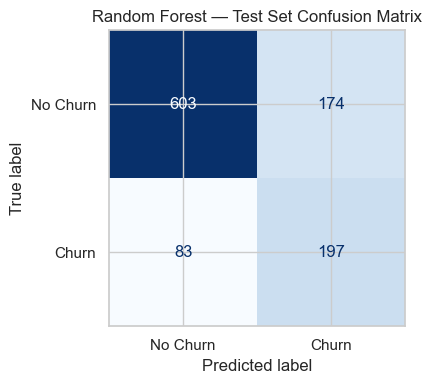

In [33]:
# Test set confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, test_preds), display_labels=['No Churn', 'Churn']
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'{best_name} — Test Set Confusion Matrix')
plt.tight_layout()
plt.savefig('artifacts/test_cm.png', dpi=120)
plt.show()

### Model Selection Justification

**Chosen model: Random Forest** (best variant — RF or RF+SMOTE — selected automatically by validation ROC-AUC)

| Reason | Detail |
|---|---|
| Best Validation ROC-AUC | **0.8344** — highest among all 5 models on the held-out validation set |
| Best Validation F1 | **0.6368** — best precision-recall balance given 26.5% class imbalance |
| SMOTE comparison | RF+SMOTE trained and compared; final model selected by `val_roc_auc` |
| Interpretable | Feature importance directly readable from the tree ensemble |
| vs LightGBM | +1.65 pp ROC-AUC, +2.59 pp F1 on validation |
| vs Logistic Regression | +0.53 pp ROC-AUC, +2.32 pp F1 for moderate complexity increase |

Full run comparison (params, metrics, artifacts) is available in MLflow — run `mlflow ui`.

---
## Section 8 â€” Save Artifacts

**Requirement 4.3:** Artifacts saved locally (for Docker) **and** also logged to the MLflow run so they are versioned and downloadable from the UI.

In [34]:
MODEL_VERSION = 'rf-v1'

# ── Save locally (Docker COPY will pick these up) ────────────────────────
joblib.dump(preprocessor, 'artifacts/preprocessor.pkl')
joblib.dump(best_model,   'artifacts/model.pkl')

schema = {
    'model_version':        MODEL_VERSION,
    'numeric_features':     NUMERIC_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'binary_features':      BINARY_FEATURES,
    'all_features':         ALL_FEATURES,
    'test_metrics':         test_metrics
}
with open('artifacts/schema.json', 'w') as f:
    json.dump(schema, f, indent=2)

# ── Also attach artifacts to the MLflow run ──────────────────────────────
with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact('artifacts/preprocessor.pkl')
    mlflow.log_artifact('artifacts/schema.json')
    mlflow.log_artifact('artifacts/model_comparison.png')
    mlflow.log_artifact('artifacts/roc_curves.png')
    mlflow.log_artifact('artifacts/feature_importance.png')
    mlflow.log_artifact('artifacts/test_cm.png')

print('Local artifacts:')
for fn in os.listdir('artifacts'):
    size = os.path.getsize(f'artifacts/{fn}')
    print(f'  artifacts/{fn:<30s}  {size/1024:.1f} KB')
print(f'\nAll artifacts logged to MLflow run: {best_run_id[:16]}...')
print('View them at: http://localhost:5000  (after running: mlflow ui)')

Local artifacts:
  artifacts/baseline_cm.png                 29.7 KB
  artifacts/eda_categorical.png             97.1 KB
  artifacts/eda_numeric.png                 34.6 KB
  artifacts/eda_target.png                  39.5 KB
  artifacts/feature_importance.png          53.3 KB
  artifacts/model.pkl                       11570.0 KB
  artifacts/model_comparison.png            41.3 KB
  artifacts/preprocessor.pkl                7.7 KB
  artifacts/roc_curves.png                  82.7 KB
  artifacts/schema.json                     1.1 KB
  artifacts/test_cm.png                     19.9 KB

All artifacts logged to MLflow run: d96dc6e658ad4ef1...
View them at: http://localhost:5000  (after running: mlflow ui)


---
## Section 9 â€” Inference Function

Verify the saved artifacts work end-to-end â€” this is exactly what [api/main.py](api/main.py) does at runtime.

In [35]:
def predict_churn(customer: dict) -> dict:
    """Load artifacts from disk and return a churn prediction for one customer."""
    _pre    = joblib.load('artifacts/preprocessor.pkl')
    _model  = joblib.load('artifacts/model.pkl')
    with open('artifacts/schema.json') as f:
        _schema = json.load(f)

    row  = pd.DataFrame([customer])[_schema['all_features']]
    proc = _pre.transform(row)
    prob = float(_model.predict_proba(proc)[0, 1])

    return {
        'churn_probability': round(prob, 4),
        'churn_prediction':  bool(prob >= 0.5),
        'model_version':     _schema['model_version']
    }


# High-risk: new customer, fiber optic, month-to-month
print('High-risk:')
print(json.dumps(predict_churn({
    'tenure':2,'MonthlyCharges':89.5,'TotalCharges':179.0,'SeniorCitizen':0,
    'gender':'Female','Partner':'No','Dependents':'No','PhoneService':'Yes',
    'MultipleLines':'Yes','InternetService':'Fiber optic','OnlineSecurity':'No',
    'OnlineBackup':'No','DeviceProtection':'No','TechSupport':'No',
    'StreamingTV':'Yes','StreamingMovies':'Yes','Contract':'Month-to-month',
    'PaperlessBilling':'Yes','PaymentMethod':'Electronic check'
}), indent=2))

# Low-risk: long-tenure, two-year contract, DSL
print('\nLow-risk:')
print(json.dumps(predict_churn({
    'tenure':60,'MonthlyCharges':45.0,'TotalCharges':2700.0,'SeniorCitizen':0,
    'gender':'Male','Partner':'Yes','Dependents':'Yes','PhoneService':'Yes',
    'MultipleLines':'No','InternetService':'DSL','OnlineSecurity':'Yes',
    'OnlineBackup':'Yes','DeviceProtection':'Yes','TechSupport':'Yes',
    'StreamingTV':'No','StreamingMovies':'No','Contract':'Two year',
    'PaperlessBilling':'No','PaymentMethod':'Bank transfer (automatic)'
}), indent=2))

High-risk:
{
  "churn_probability": 0.9347,
  "churn_prediction": true,
  "model_version": "rf-v1"
}

Low-risk:
{
  "churn_probability": 0.013,
  "churn_prediction": false,
  "model_version": "rf-v1"
}


---
## Section 10 â€” Deployment

All deployment files already exist as **standalone files** in the project folder. This section is a reference summary.

| File | Purpose |
|---|---|
| [api/main.py](api/main.py) | FastAPI app â€” `/health`, `/predict`, `/metrics` |
| [api/requirements.txt](api/requirements.txt) | API dependencies |
| [Dockerfile](Dockerfile) | Builds the container image |
| [docker-compose.yml](docker-compose.yml) | API + Prometheus + Grafana |
| [deployment/k8s-deployment.yaml](deployment/k8s-deployment.yaml) | 2-replica K8s deployment + LoadBalancer + Ingress |
| [monitoring/prometheus.yml](monitoring/prometheus.yml) | Prometheus scrape config |
| [tests/test_api.py](tests/test_api.py) | FastAPI unit tests |
| [tests/test_preprocess.py](tests/test_preprocess.py) | Preprocessor unit tests |

### Run locally

```bash
# Full stack: API + Prometheus + Grafana
docker-compose up -d

# MLflow experiment tracking UI
mlflow ui

# Run tests
pytest tests/ -v
```

| Service | URL |
|---|---|
| API | http://localhost:8000 |
| API docs | http://localhost:8000/docs |
| Prometheus | http://localhost:9090 |
| Grafana | http://localhost:3000 (admin/admin) |
| MLflow UI | http://localhost:5000 |

### Deploy to cloud VM

```bash
docker tag churn-api YOUR_USERNAME/churn-api:latest
docker push YOUR_USERNAME/churn-api:latest

# On the VM:
docker pull YOUR_USERNAME/churn-api:latest
docker run -d -p 80:8000 YOUR_USERNAME/churn-api:latest

# Test from anywhere:
curl http://YOUR_VM_PUBLIC_IP/health
```

### Deploy to Kubernetes

```bash
kubectl apply -f deployment/k8s-deployment.yaml
kubectl get service churn-api-service   # wait for EXTERNAL-IP
```